# Jumbotail - Replenishment Planner Assignment

**Candidate:** Kattubadi Mohammad

**Assignment Date:** 2026-03-16

## Objective

Build a replenishment planner that generates purchase order suggestions while considering:

- Current inventory
- Open purchase orders
- Inventory norms
- Safety stock
- Case rounding
- Space constraints
- MOV compliance

---

## 1. Import Required Libraries

Import all the required Python libraries used throughout the replenishment planning pipeline.

In [99]:
import pandas as pd
import numpy as np
import json
import sqlite3
from datetime import datetime

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Set Planning Date

The assignment specifies **16 March 2026** as the replenishment planning date. All inventory calculations are performed relative to this date.

In [100]:
planning_date = pd.Timestamp("2026-03-16")

print("Planning Date:", planning_date)

Planning Date: 2026-03-16 00:00:00


## 3. Load Dataset

Load the replenishment dataset into a pandas DataFrame and verify that it has been loaded successfully.

In [101]:
df = pd.read_csv("../data/assignment_data.csv")

print("Dataset Loaded Successfully!")
print(df.shape)
df.head()

Dataset Loaded Successfully!
(1389, 36)


,facility_id,category_name,manufacturername,facility_name,jpin,title,pvname,vendor_lead_time,inv_norm,safety_stock,vendor_id,vendor_name,current_vendor_mov,minimum_order_criteria,max_allocated_space,case_size,cases_allocated,space_value,current_inventory,inventory_breakup,max_drr,deadweight,earliest_promise_date,open_po_details,orderedquantity,open_po_value,open_po_cases,final_suggestion,final_days_of_inventory,final_cases_suggestion,final_value,final_tonnage,mov_check,mrp,cp,sales_band
0,FC-001,Baby Care,Colgate-Palmolive,FC-Alpha,SKU-00786,"Colgate Super Junior Toothbrush, Ultra Soft, 2...",Baby Toothbrush,5,26,4,VND-052,COLGATE PALMOLIVE INDIA LTD - Region Beta,120000,VALUE,48,24,2.0,5511.0,0,"{""sellable"": null, ""contingency"": null, ""pendi...",0,0.000,18/03/26,"{""open_po_1"": {""promise_date"": ""2026-03-18"", ""...",24,2755.0,1.0,0,0,0,0,0,NaN,155.90,129.75,NaN
1,FC-001,Baby Care,Dabur India Limited,FC-Alpha,SKU-00726,"Dabur Lal Tail, 50ml Box",Baby Oil,5,9,4,VND-054,DABUR INDIA LIMITED - Region Epsilon,30000,VALUE,240,120,2.0,13074.0,22,"{""sellable"": 22.0, ""contingency"": null, ""pendi...",6,0.068,19/03/26,"{""open_po_1"": {""promise_date"": ""2026-03-19"", ""...",120,6536.0,1.0,0,0,0,0,0,NaN,79.47,51.47,Band B
2,FC-001,Baby Care,Dabur India Limited,FC-Alpha,SKU-00846,"Dabur Lal Tail, 100ml Box",Baby Oil,5,9,4,VND-054,DABUR INDIA LIMITED - Region Epsilon,30000,VALUE,120,60,2.0,13074.0,32,"{""sellable"": 32.0, ""contingency"": null, ""pendi...",2,0.121,NaN,NaN,0,0.0,0.0,0,0,0,0,0,NaN,149.74,109.19,Band C
3,FC-001,Beverages,Dabur India Limited,FC-Alpha,SKU-00352,"Real Koolerz Fruit Drink, Mango, 10Rs Tetra Pak",Fruit Drinks,5,14,4,VND-054,DABUR INDIA LIMITED - Region Epsilon,30000,VALUE,800,40,20.0,6076.0,0,"{""sellable"": null, ""contingency"": null, ""pendi...",118,0.167,19/03/26,"{""open_po_1"": {""promise_date"": ""2026-03-19"", ""...",1000,7590.0,25.0,0,0,0,0,0,NaN,8.84,6.94,Band C
4,FC-001,Beverages,Dabur India Limited,FC-Alpha,SKU-00725,"Real Fruit Power Drink, Guava, 180ml Tetra Pak",Fruit Drinks,5,14,4,VND-054,DABUR INDIA LIMITED - Region Epsilon,30000,VALUE,600,30,20.0,9620.0,467,"{""sellable"": 452.0, ""contingency"": 15.0, ""pend...",35,0.200,NaN,"{""open_po_1"": {""promise_date"": null, ""orderedq...",210,3366.0,7.0,0,0,0,0,0,NaN,16.85,16.79,Band C


## 4. Explore the Dataset

Perform an initial exploratory analysis to understand the dataset structure, identify missing values, inspect column names, and verify data types before building the replenishment logic.

In [102]:
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print(df.shape)

print("\n")

print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)

print(df.columns.tolist())

DATASET SHAPE
(1389, 36)


COLUMN NAMES
['facility_id', 'category_name', 'manufacturername', 'facility_name', 'jpin', 'title', 'pvname', 'vendor_lead_time', 'inv_norm', 'safety_stock', 'vendor_id', 'vendor_name', 'current_vendor_mov', 'minimum_order_criteria', 'max_allocated_space', 'case_size', 'cases_allocated', 'space_value', 'current_inventory', 'inventory_breakup', 'max_drr', 'deadweight', 'earliest_promise_date', 'open_po_details', 'orderedquantity', 'open_po_value', 'open_po_cases', 'final_suggestion', 'final_days_of_inventory', 'final_cases_suggestion', 'final_value', 'final_tonnage', 'mov_check', 'mrp', 'cp', 'sales_band']


In [103]:
print("=" * 60)
print("DATA TYPES")
print("=" * 60)

display(df.dtypes)

DATA TYPES


facility_id          object
category_name        object
manufacturername     object
facility_name        object
jpin                 object
                     ...   
final_tonnage         int64
mov_check           float64
mrp                 float64
cp                  float64
sales_band           object
Length: 36, dtype: object

In [104]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = df.isnull().sum()

display(missing[missing > 0].sort_values(ascending=False))

MISSING VALUES


mov_check                1389
open_po_details           833
earliest_promise_date     640
sales_band                167
dtype: int64

In [105]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

display(df.describe())

SUMMARY STATISTICS


,vendor_lead_time,inv_norm,safety_stock,current_vendor_mov,max_allocated_space,case_size,cases_allocated,space_value,current_inventory,max_drr,deadweight,orderedquantity,open_po_value,open_po_cases,final_suggestion,final_days_of_inventory,final_cases_suggestion,final_value,final_tonnage,mov_check,mrp,cp
count,1389.00000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.000000,1389.0,1389.0,1389.0,1389.0,1389.0,0.0,1389.000000,1389.000000
mean,3.12239,15.831533,4.303096,99408.675306,1366.748020,193.888409,13.797719,15866.067746,543.064075,111.933045,0.191490,815.886969,5764.519842,6.391566,0.0,0.0,0.0,0.0,0.0,NaN,56.262851,43.035169
std,1.70336,5.367515,0.901247,77734.899328,3174.250632,381.635810,38.412534,26477.527303,2101.034350,311.817239,0.293125,2400.412330,17488.727016,26.319014,0.0,0.0,0.0,0.0,0.0,NaN,72.840540,55.354102
min,1.00000,7.000000,4.000000,100.000000,6.000000,6.000000,0.000000,128.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,0.870000,0.820000
25%,2.00000,13.000000,4.000000,30000.000000,120.000000,30.000000,2.000000,3950.000000,3.000000,1.000000,0.030000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,10.200000,7.890000
50%,3.00000,15.000000,4.000000,70000.000000,360.000000,72.000000,2.000000,8154.763637,47.000000,10.000000,0.075000,48.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,30.640000,23.670000
75%,4.00000,17.000000,4.000000,200000.000000,1080.000000,216.000000,8.000000,15840.000000,261.000000,74.000000,0.220000,480.000000,3967.200000,2.000000,0.0,0.0,0.0,0.0,0.0,NaN,74.070000,56.150000
max,8.00000,35.000000,16.000000,300000.000000,31104.000000,9216.000000,401.000000,272312.640000,40015.000000,3422.000000,3.010000,22176.000000,232903.000000,458.000000,0.0,0.0,0.0,0.0,0.0,NaN,883.430000,551.400000


## 5. Parse JSON Columns

The columns **inventory_breakup** and **open_po_details** are stored as JSON strings. Convert them into Python dictionaries to simplify downstream calculations.

In [106]:
def parse_json(value):

    if pd.isna(value):
        return {}

    try:
        return json.loads(value)

    except Exception:
        return {}

In [107]:
df["inventory_breakup"] = df["inventory_breakup"].apply(parse_json)

df["open_po_details"] = df["open_po_details"].apply(parse_json)

print("JSON Parsing Completed Successfully")

JSON Parsing Completed Successfully


In [108]:
df[["inventory_breakup", "open_po_details"]].head()

,inventory_breakup,open_po_details
0,"{'sellable': None, 'contingency': None, 'pendi...","{'open_po_1': {'promise_date': '2026-03-18', '..."
1,"{'sellable': 22.0, 'contingency': None, 'pendi...","{'open_po_1': {'promise_date': '2026-03-19', '..."
2,"{'sellable': 32.0, 'contingency': None, 'pendi...",{}
3,"{'sellable': None, 'contingency': None, 'pendi...","{'open_po_1': {'promise_date': '2026-03-19', '..."
4,"{'sellable': 452.0, 'contingency': 15.0, 'pend...","{'open_po_1': {'promise_date': None, 'orderedq..."


## 6. Calculate Current Days of Inventory

Current Days of Inventory (DOI) indicates how many days the current inventory can satisfy demand based on the Daily Run Rate (DRR).

Formula:

Current DOI = Current Inventory / Max DRR

If Max DRR is zero, Current DOI is considered zero.

In [109]:
df["current_days_inventory"] = np.where(
    df["max_drr"] > 0,
    df["current_inventory"] / df["max_drr"],
    0
)

df[[
    "jpin",
    "current_inventory",
    "max_drr",
    "current_days_inventory"
]].head()

,jpin,current_inventory,max_drr,current_days_inventory
0,SKU-00786,0,0,0.000000
1,SKU-00726,22,6,3.666667
2,SKU-00846,32,2,16.000000
3,SKU-00352,0,118,0.000000
4,SKU-00725,467,35,13.342857


## 7. Calculate Target Inventory

Target Inventory represents the ideal inventory level that should be available after replenishment.

Formula:

Target Inventory = (Inventory Norm + Safety Stock) × Daily Run Rate

In [110]:
df["target_inventory"] = (
    (df["inv_norm"] + df["safety_stock"])
    * df["max_drr"]
)

print("Target Inventory Calculated Successfully")

df[[
    "jpin",
    "inv_norm",
    "safety_stock",
    "max_drr",
    "target_inventory"
]].head()

Target Inventory Calculated Successfully


,jpin,inv_norm,safety_stock,max_drr,target_inventory
0,SKU-00786,26,4,0,0
1,SKU-00726,9,4,6,78
2,SKU-00846,9,4,2,26
3,SKU-00352,14,4,118,2124
4,SKU-00725,14,4,35,630


## 8. Calculate Available Inventory

Available Inventory includes both the current on-hand inventory and inventory already expected through open purchase orders.

In [111]:
df["available_inventory"] = (
    df["current_inventory"]
    + df["orderedquantity"]
)

print("Available Inventory Calculated Successfully")

df[[
    "jpin",
    "current_inventory",
    "orderedquantity",
    "available_inventory"
]].head()

Available Inventory Calculated Successfully


,jpin,current_inventory,orderedquantity,available_inventory
0,SKU-00786,0,24,24
1,SKU-00726,22,120,142
2,SKU-00846,32,0,32
3,SKU-00352,0,1000,1000
4,SKU-00725,467,210,677


## 9. Calculate Inventory Gap

Inventory Gap represents the additional quantity required to achieve the target inventory after considering the available inventory.

Formula:

Inventory Gap = Target Inventory − Available Inventory

Negative values are converted to zero since no replenishment is required in those cases.

In [112]:
df["inventory_gap"] = (
    df["target_inventory"]
    - df["available_inventory"]
)

df["inventory_gap"] = df["inventory_gap"].clip(lower=0)

print("Inventory Gap Calculated Successfully")

df[[
    "jpin",
    "target_inventory",
    "available_inventory",
    "inventory_gap"
]].head()

Inventory Gap Calculated Successfully


,jpin,target_inventory,available_inventory,inventory_gap
0,SKU-00786,0,24,0
1,SKU-00726,78,142,0
2,SKU-00846,26,32,0
3,SKU-00352,2124,1000,1124
4,SKU-00725,630,677,0


## 10. Analyze Inventory Position

Review the calculated inventory metrics before applying replenishment constraints such as case-size rounding, storage limits, and vendor Minimum Order Value (MOV).

In [113]:
inventory_summary = df[[
    "jpin",
    "current_inventory",
    "orderedquantity",
    "available_inventory",
    "max_drr",
    "current_days_inventory",
    "target_inventory",
    "inventory_gap"
]]

inventory_summary.head(10)

,jpin,current_inventory,orderedquantity,available_inventory,max_drr,current_days_inventory,target_inventory,inventory_gap
0,SKU-00786,0,24,24,0,0.000000,0,0
1,SKU-00726,22,120,142,6,3.666667,78,0
2,SKU-00846,32,0,32,2,16.000000,26,0
3,SKU-00352,0,1000,1000,118,0.000000,2124,1124
4,SKU-00725,467,210,677,35,13.342857,630,0
5,SKU-00780,179,870,1049,154,1.162338,2772,1723
6,SKU-00781,15,660,675,156,0.096154,2808,2133
7,SKU-00045,1,300,301,23,0.043478,483,182
8,SKU-00374,9,100,109,43,0.209302,903,794
9,SKU-00500,63,144,207,5,12.600000,105,0


## 11. Apply Case Size Rounding

Purchase Orders must always be placed in whole cases.

The calculated inventory gap is rounded up to the nearest multiple of the SKU case size.

In [114]:
import math

def round_to_case(quantity, case_size):
    if pd.isna(quantity) or quantity <= 0:
        return 0

    if pd.isna(case_size) or case_size <= 0:
        return int(quantity)

    return int(math.ceil(quantity / case_size) * case_size)

df["rounded_quantity"] = df.apply(
    lambda row: round_to_case(
        row["inventory_gap"],
        row["case_size"]
    ),
    axis=1
)

print("Case-size rounding completed.")

df[[
    "jpin",
    "inventory_gap",
    "case_size",
    "rounded_quantity"
]].head()

Case-size rounding completed.


,jpin,inventory_gap,case_size,rounded_quantity
0,SKU-00786,0,24,0
1,SKU-00726,0,120,0
2,SKU-00846,0,60,0
3,SKU-00352,1124,40,1160
4,SKU-00725,0,30,0


## 12. Apply Storage Space Constraints

The suggested replenishment quantity should not exceed the available storage capacity allocated for each SKU.

In [115]:
df["available_inventory"] = (
    df["current_inventory"]
    + df["orderedquantity"]
)

remaining_space = (
    df["max_allocated_space"]
    - df["available_inventory"]
)

remaining_space = remaining_space.clip(lower=0)

df["final_suggestion"] = np.minimum(
    df["rounded_quantity"],
    remaining_space
)

print("Storage constraints applied successfully.")

df[[
    "jpin",
    "rounded_quantity",
    "available_inventory",
    "max_allocated_space",
    "final_suggestion"
]].head()

Storage constraints applied successfully.


,jpin,rounded_quantity,available_inventory,max_allocated_space,final_suggestion
0,SKU-00786,0,24,48,0
1,SKU-00726,0,142,240,0
2,SKU-00846,0,32,120,0
3,SKU-00352,1160,1000,800,0
4,SKU-00725,0,677,600,0


## 13. Calculate Final Purchase Order Metrics

Calculate the recommended order quantity, number of cases, inventory coverage, order value, and tonnage for each SKU.

In [116]:
df["final_cases_suggestion"] = (
    df["final_suggestion"] / df["case_size"]
).fillna(0)

df["final_value"] = (
    df["final_suggestion"] * df["cp"]
).round(2)

df["final_days_of_inventory"] = np.where(
    df["max_drr"] > 0,
    (df["current_inventory"] + df["final_suggestion"])
    / df["max_drr"],
    0
)

df["final_tonnage"] = (
    df["final_suggestion"] * df["deadweight"]
).round(3)

print("Purchase metrics calculated.")

df[[
    "jpin",
    "final_suggestion",
    "final_cases_suggestion",
    "final_value",
    "final_days_of_inventory"
]].head()

Purchase metrics calculated.


,jpin,final_suggestion,final_cases_suggestion,final_value,final_days_of_inventory
0,SKU-00786,0,0.0,0.0,0.000000
1,SKU-00726,0,0.0,0.0,3.666667
2,SKU-00846,0,0.0,0.0,16.000000
3,SKU-00352,0,0.0,0.0,0.000000
4,SKU-00725,0,0.0,0.0,13.342857


## 14. Validate Vendor Minimum Order Value (MOV)

Purchase orders are validated against the vendor's Minimum Order Value (MOV). Vendors meeting the threshold are marked as compliant.

In [117]:
vendor_summary = (
    df.groupby("vendor_id")
    .agg(
        total_order_value=("final_value", "sum"),
        mov=("current_vendor_mov", "first")
    )
    .reset_index()
)

vendor_summary["mov_check"] = np.where(
    vendor_summary["total_order_value"] >= vendor_summary["mov"],
    "PASS",
    "FAIL"
)

df = df.merge(
    vendor_summary[["vendor_id", "mov_check"]],
    on="vendor_id",
    how="left"
)

print("Vendor MOV validation completed.")

vendor_summary.head()

Vendor MOV validation completed.


,vendor_id,total_order_value,mov,mov_check
0,VND-001,5767.00,10000,FAIL
1,VND-002,0.00,10000,FAIL
2,VND-003,48998.23,200000,FAIL
3,VND-004,0.00,10000,FAIL
4,VND-005,104479.14,80000,PASS


## 15. Export Final Output

Export the final replenishment recommendations for further reporting and downstream processing.

In [118]:
df.to_csv(
    "../reports/replenishment_output.csv",
    index=False
)

print("Output exported successfully.")

Output exported successfully.


## 16. Load Data into SQLite Database

Store the replenishment output in a SQLite database to enable SQL-based reporting and analysis.

In [119]:
import json

df_sql = df.copy()

df_sql["inventory_breakup"] = df_sql["inventory_breakup"].apply(
    lambda x: json.dumps(x) if isinstance(x, dict) else x
)

df_sql["open_po_details"] = df_sql["open_po_details"].apply(
    lambda x: json.dumps(x) if isinstance(x, dict) else x
)

print("JSON columns converted successfully!")

JSON columns converted successfully!


In [120]:
import sqlite3

conn = sqlite3.connect("../database/replenishment.db")

df_sql.to_sql(
    "replenishment",
    conn,
    if_exists="replace",
    index=False
)

conn.close()

print("SQLite database created successfully!")

SQLite database created successfully!


## 17. Execute SQL Queries

Run SQL queries to analyze replenishment recommendations and vendor performance.

In [121]:
import sqlite3

conn = sqlite3.connect("../database/replenishment.db")
print("Connected successfully!")

Connected successfully!


In [122]:
pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,replenishment


In [123]:
pd.read_sql(
    "PRAGMA table_info(replenishment);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,facility_id,TEXT,0,None,0
1,1,category_name,TEXT,0,None,0
2,2,manufacturername,TEXT,0,None,0
3,3,facility_name,TEXT,0,None,0
4,4,jpin,TEXT,0,None,0
...,...,...,...,...,...,...
37,37,target_inventory,INTEGER,0,None,0
38,38,available_inventory,INTEGER,0,None,0
39,39,inventory_gap,INTEGER,0,None,0
40,40,rounded_quantity,INTEGER,0,None,0


In [124]:
query1 = """
SELECT
    category_name,
    SUM(final_value) AS total_order_value
FROM replenishment
GROUP BY category_name
ORDER BY total_order_value DESC;
"""

category_summary = pd.read_sql(query1, conn)

category_summary.head()

,category_name,total_order_value
0,"Biscuit, Confectionary & Snacks",561681.61
1,Personal Care,475933.05
2,Home Care,235684.04
3,Grounded Spices & Masalas,157475.81
4,Beverages,150974.67


In [125]:
query2 = """
SELECT
    vendor_name,
    COUNT(jpin) AS total_skus,
    SUM(final_suggestion) AS total_units,
    SUM(final_cases_suggestion) AS total_cases,
    SUM(final_value) AS total_order_value,
    ROUND(AVG(final_value), 2) AS avg_order_value
FROM replenishment
GROUP BY vendor_name
ORDER BY total_order_value DESC;
"""

vendor_report = pd.read_sql(query2, conn)

vendor_report.head()

,vendor_name,total_skus,total_units,total_cases,total_order_value,avg_order_value
0,GODREJ CONSUMER PRODUCTS LTD - Region Beta,27,18068,77.014753,179552.67,6650.10
1,SHRI KRISHNA MURARI ENTERPRISES - Region Epsilon,25,18386,70.292531,165670.63,6626.83
2,SRI SAI TRADERS - Region Alpha,66,10456,21.600278,104479.14,1583.02
3,Real Time Logistics - Region Epsilon,2,2241,93.375000,99164.25,49582.13
4,RECKITT BENCKISER INDIA Private Limited - Regi...,36,1111,26.450893,91497.85,2541.61


## 18. Visualizations

The following charts summarize the replenishment recommendations and inventory risk.

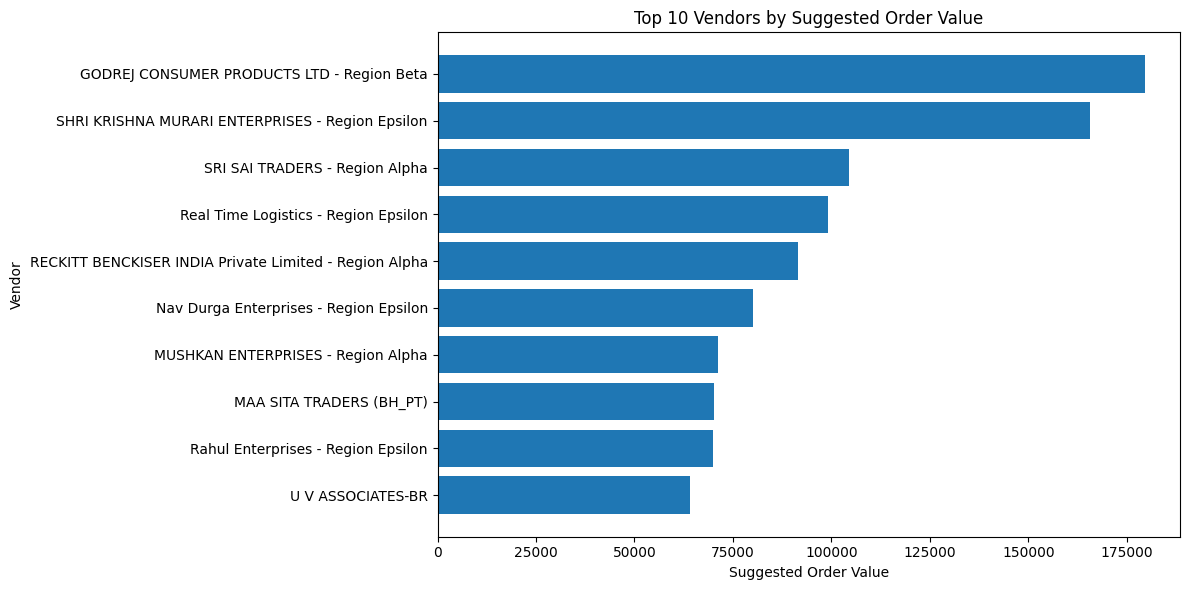

In [129]:
import matplotlib.pyplot as plt

top10 = vendor_report.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["vendor_name"],
    top10["total_order_value"]
)

plt.title("Top 10 Vendors by Suggested Order Value")
plt.xlabel("Suggested Order Value")
plt.ylabel("Vendor")

plt.gca().invert_yaxis()  # Highest value at the top

plt.tight_layout()
plt.show()

In [130]:
query3 = """
SELECT
    facility_name,
    vendor_name,
    title,
    current_days_inventory
FROM replenishment
WHERE max_drr > 0
ORDER BY current_days_inventory ASC
LIMIT 10;
"""

risk_skus = pd.read_sql(query3, conn)

risk_skus

,facility_name,vendor_name,title,current_days_inventory
0,FC-Alpha,DABUR INDIA LIMITED - Region Epsilon,"Real Koolerz Fruit Drink, Mango, 10Rs Tetra Pak",0.0
1,FC-Alpha,SIDDHI VINAYAK TRADERS - Region Alpha,"Cipla Prolyte ORS, Mixed Fruit, 200ml Tetra Pak",0.0
2,FC-Alpha,SIDDHI VINAYAK TRADERS - Region Alpha,"Cipla Prolyte ORS, Nimbu Paani, 200ml Tetra Pak",0.0
3,FC-Alpha,SIDDHI VINAYAK TRADERS - Region Alpha,"Cipla Prolyte ORS, Apple, 200ml Tetra Pak",0.0
4,FC-Alpha,SIDDHI VINAYAK TRADERS - Region Alpha,"Campa Soft Drink, Orange, 500ml Bottle",0.0
5,FC-Alpha,SIDDHI VINAYAK TRADERS - Region Alpha,"Campa Soft Drink, Cola, 200ml Bottle",0.0
6,FC-Alpha,Shree Krishna Enterprises - Region Epsilon,"Campa Soft Drink, Cola, 200ml Bottle",0.0
7,FC-Alpha,SIDDHI VINAYAK TRADERS - Region Alpha,"Campa Soft Drink, Orange, 200ml Bottle",0.0
8,FC-Alpha,Shree Krishna Enterprises - Region Epsilon,"Campa Soft Drink, Orange, 200ml Bottle",0.0
9,FC-Alpha,SLMG BEVERAGES PRIVATE LIMITED - Region Alpha,"Limca Soft Drink, 2L Bottle",0.0


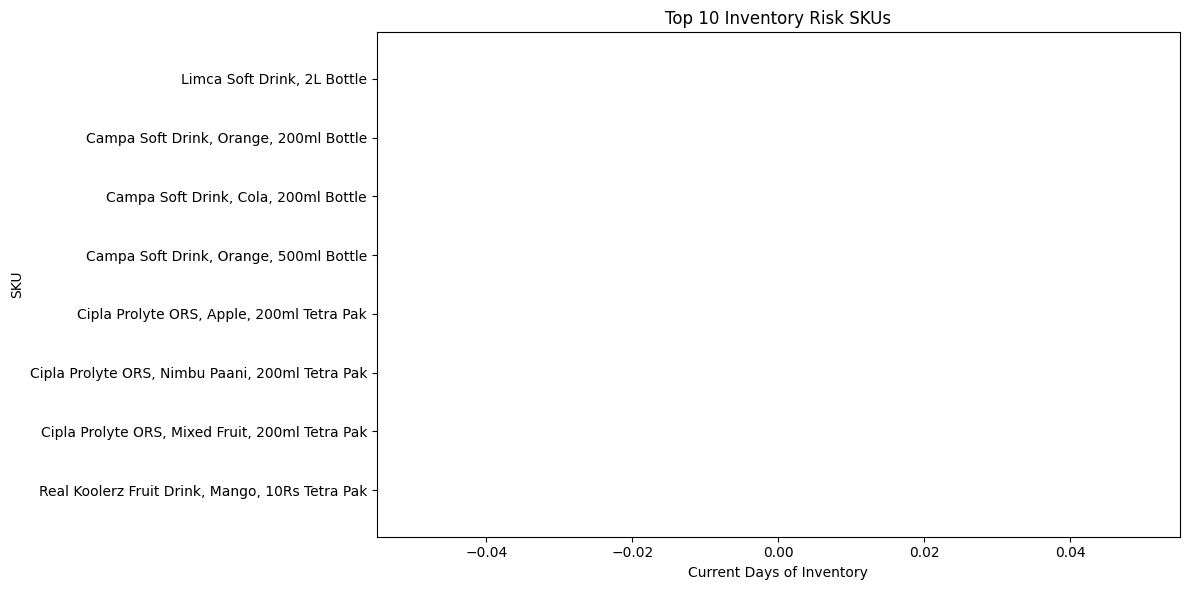

In [131]:
plt.figure(figsize=(12,6))

plt.barh(
    risk_skus["title"],
    risk_skus["current_days_inventory"]
)

plt.xlabel("Current Days of Inventory")
plt.ylabel("SKU")

plt.title("Top 10 Inventory Risk SKUs")

plt.tight_layout()
plt.show()

# 20. Conclusion

## Key Assumptions

- Planning date is 16 March 2026.
- Existing purchase orders contribute to future inventory.
- Orders are rounded to full case sizes.
- Suggested quantity does not exceed allocated storage capacity.
- Vendor MOV is validated based on the assignment rules.

## Business Rules Implemented

- Inventory Norm
- Safety Stock
- Daily Run Rate
- Inventory Gap
- Case Size Rounding
- Space Constraints
- Purchase Order Suggestion
- MOV Validation

## Future Improvements

- Demand forecasting using historical sales
- Lead-time aware replenishment
- Multi-warehouse inventory balancing
- Vendor-level PO optimization
- Interactive Streamlit dashboard